In [1]:
import sys
sys.path.append('..')

import torch
from torch.utils.data import DataLoader

from src.model import ECG_CNN1D
from src.dataset import ECGDataset
from src.losses import FocalLossMultiLabel
from src.train import entrenar_una_epoca, evaluar

dispositivo = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Usando dispositivo:", dispositivo)

Usando dispositivo: cpu


In [2]:
train_dataset = ECGDataset('../data/processed/X_train.npy', '../data/processed/y_train.npy')
val_dataset = ECGDataset('../data/processed/X_val.npy', '../data/processed/y_val.npy')

# num_workers=0: en Windows + Jupyter, valores mayores pueden causar errores
# de multiprocessing. Con un dataset de este tamaño, 0 es igualmente rápido.
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)

print(f"Ejemplos de entrenamiento: {len(train_dataset)}")
print(f"Ejemplos de validación: {len(val_dataset)}")

Ejemplos de entrenamiento: 17074
Ejemplos de validación: 2144


In [3]:
modelo = ECG_CNN1D(num_leads=12, num_classes=5).to(dispositivo)
funcion_perdida = FocalLossMultiLabel(alpha=0.25, gamma=2.0)
optimizador = torch.optim.Adam(modelo.parameters(), lr=1e-3)

SMOKE TEST:

In [4]:
from torch.utils.data import Subset

subset_train = Subset(train_dataset, range(200))
subset_val = Subset(val_dataset, range(100))

subset_train_loader = DataLoader(subset_train, batch_size=32, shuffle=True, num_workers=0)
subset_val_loader = DataLoader(subset_val, batch_size=32, shuffle=False, num_workers=0)

modelo_prueba = ECG_CNN1D(num_leads=12, num_classes=5).to(dispositivo)
optimizador_prueba = torch.optim.Adam(modelo_prueba.parameters(), lr=1e-3)

for epoca in range(2):
    perdida_train = entrenar_una_epoca(modelo_prueba, subset_train_loader, funcion_perdida, optimizador_prueba, dispositivo)
    perdida_val, _, _ = evaluar(modelo_prueba, subset_val_loader, funcion_perdida, dispositivo)
    print(f"Época {epoca+1}: pérdida train={perdida_train:.4f}, pérdida val={perdida_val:.4f}")

Época 1: pérdida train=0.0919, pérdida val=0.0923


Época 2: pérdida train=0.0598, pérdida val=0.0657


In [5]:
import os
os.makedirs('../models', exist_ok=True)

from sklearn.metrics import roc_auc_score

NUM_EPOCAS = 20
mejor_auroc_val = 0.0
mejor_epoca = 0

historial = {'perdida_train': [], 'perdida_val': [], 'auroc_val': []}

for epoca in range(NUM_EPOCAS):
    perdida_train = entrenar_una_epoca(modelo, train_loader, funcion_perdida, optimizador, dispositivo)
    perdida_val, predicciones_val, etiquetas_val = evaluar(modelo, val_loader, funcion_perdida, dispositivo)
    auroc_val = roc_auc_score(etiquetas_val, predicciones_val, average='macro')

    historial['perdida_train'].append(perdida_train)
    historial['perdida_val'].append(perdida_val)
    historial['auroc_val'].append(auroc_val)

    print(f"Época {epoca+1}/{NUM_EPOCAS} | Pérdida train: {perdida_train:.4f} | Pérdida val: {perdida_val:.4f} | AUROC val (macro): {auroc_val:.4f}")

    if auroc_val > mejor_auroc_val:
        mejor_auroc_val = auroc_val
        mejor_epoca = epoca + 1
        torch.save(modelo.state_dict(), '../models/mejor_modelo.pt')
        print(f"  → Nuevo mejor modelo guardado (AUROC: {auroc_val:.4f})")

print(f"\nEntrenamiento completo. Mejor AUROC macro: {mejor_auroc_val:.4f} (época {mejor_epoca})")

Época 1/20 | Pérdida train: 0.0393 | Pérdida val: 0.0340 | AUROC val (macro): 0.8825
  → Nuevo mejor modelo guardado (AUROC: 0.8825)


Época 2/20 | Pérdida train: 0.0339 | Pérdida val: 0.0338 | AUROC val (macro): 0.8896
  → Nuevo mejor modelo guardado (AUROC: 0.8896)


Época 3/20 | Pérdida train: 0.0329 | Pérdida val: 0.0327 | AUROC val (macro): 0.8927
  → Nuevo mejor modelo guardado (AUROC: 0.8927)


Época 4/20 | Pérdida train: 0.0320 | Pérdida val: 0.0325 | AUROC val (macro): 0.8964
  → Nuevo mejor modelo guardado (AUROC: 0.8964)


Época 5/20 | Pérdida train: 0.0316 | Pérdida val: 0.0334 | AUROC val (macro): 0.8964


...

Época 16/20 | Pérdida train: 0.0281 | Pérdida val: 0.0309 | AUROC val (macro): 0.9073


Época 17/20 | Pérdida train: 0.0277 | Pérdida val: 0.0328 | AUROC val (macro): 0.9066


Época 18/20 | Pérdida train: 0.0276 | Pérdida val: 0.0321 | AUROC val (macro): 0.9067


Época 19/20 | Pérdida train: 0.0273 | Pérdida val: 0.0319 | AUROC val (macro): 0.9062


Época 20/20 | Pérdida train: 0.0273 | Pérdida val: 0.0309 | AUROC val (macro): 0.9109
  → Nuevo mejor modelo guardado (AUROC: 0.9109)

Entrenamiento completo. Mejor AUROC macro: 0.9109 (época 20)


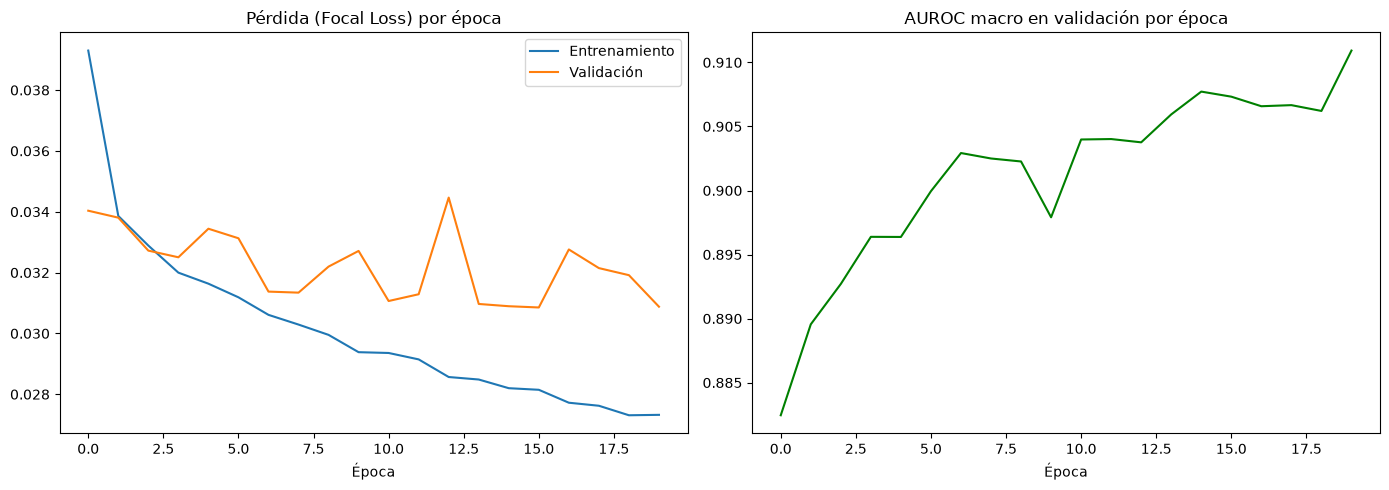

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(historial['perdida_train'], label='Entrenamiento')
axes[0].plot(historial['perdida_val'], label='Validación')
axes[0].set_title('Pérdida (Focal Loss) por época')
axes[0].set_xlabel('Época')
axes[0].legend()

axes[1].plot(historial['auroc_val'], color='green')
axes[1].set_title('AUROC macro en validación por época')
axes[1].set_xlabel('Época')

plt.tight_layout()
plt.show()